# Inventory Optimization

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/processed/retail_featured.csv")

In [17]:
# Calculate average weekly demand

inventory = (
    df.groupby(["Store", "Dept"])
      .agg(
          Avg_Demand=("Weekly_Sales", "mean"),
          Std_Demand=("Weekly_Sales", "std"),
          Max_Demand=("Weekly_Sales", "max")
      )
      .reset_index()
)

In [18]:
# Calculate Safety Stock

service_level = 1.65

inventory["Safety_Stock"] = (
    service_level *
    inventory["Std_Demand"]
)

In [19]:
# Lead Time (1 week)

lead_time = 1

In [20]:
# Reorder Point

inventory["Reorder_Point"] = (
    inventory["Avg_Demand"] * lead_time +
    inventory["Safety_Stock"]
)

In [21]:
# EOQ (Economic Order Quantity)

ordering_cost = 50
holding_cost = 2

inventory["EOQ"] = np.sqrt(
    (2 * inventory["Avg_Demand"] * ordering_cost) /
    holding_cost
)

In [22]:
# Inventory Health Score

inventory["Inventory_Health"] = np.where(
    inventory["Safety_Stock"] > inventory["Avg_Demand"],
    "High Risk",
    "Healthy"
)

In [23]:
# Result

inventory.head(10)

,Store,Dept,Avg_Demand,Std_Demand,Max_Demand,Safety_Stock,Reorder_Point,EOQ,Inventory_Health
0,1,1,22513.322937,9854.349032,57592.12,16259.675903,38772.998840,1060.974150,Healthy
1,1,2,46102.090420,3440.673222,65615.36,5677.110817,51779.201236,1518.257067,Healthy
2,1,3,13150.478042,8708.978853,51159.17,14369.815107,27520.293149,810.878476,High Risk
3,1,4,36964.154476,2930.698313,47893.23,4835.652217,41799.806693,1359.488037,Healthy
4,1,5,24257.941119,11330.286495,85676.09,18694.972717,42952.913836,1101.316056,Healthy
5,1,6,4801.780140,3317.432691,28497.52,5473.763941,10275.544081,489.988783,High Risk
6,1,7,24566.487413,18808.958465,166697.72,31034.781467,55601.268879,1108.297961,High Risk
7,1,8,35718.257622,2490.769188,42663.75,4109.769160,39828.026783,1336.380515,Healthy
8,1,9,28062.052238,8422.254593,50675.72,13896.720078,41958.772316,1184.526324,Healthy
9,1,10,31033.386364,3509.190495,43718.05,5790.164316,36823.550680,1245.660194,Healthy


In [24]:
# Top High-Risk Departments

inventory.sort_values(
    by="Safety_Stock",
    ascending=False
).head(10)

,Store,Dept,Avg_Demand,Std_Demand,Max_Demand,Safety_Stock,Reorder_Point,EOQ,Inventory_Health
736,10,72,142733.752168,74674.505691,693099.36,123212.934391,265946.686559,2671.457956,Healthy
2635,35,72,88331.808881,71265.927075,649770.18,117588.779674,205920.588555,2101.568568,High Risk
1044,14,72,94140.832867,52070.686993,474330.10,85916.633539,180057.466406,2169.571765,Healthy
1510,20,72,91989.863217,51440.261925,422306.25,84876.432177,176866.295394,2144.642898,Healthy
685,10,7,58964.715664,49692.185566,406988.63,81992.106183,140956.821848,1717.042744,High Risk
284,4,72,101244.450839,47323.714827,385051.04,78084.129465,179328.580304,2249.938342,Healthy
994,14,7,53256.150280,45807.032552,356867.25,75581.603711,128837.753990,1631.811115,High Risk
2048,27,72,68527.765944,44791.304378,420586.57,73905.652223,142433.418167,1851.050593,High Risk
1663,22,72,66645.669021,43296.446779,393705.20,71439.137186,138084.806207,1825.454314,High Risk
1740,23,72,76844.022727,42662.506657,369830.98,70393.135983,147237.158711,1960.153345,Healthy


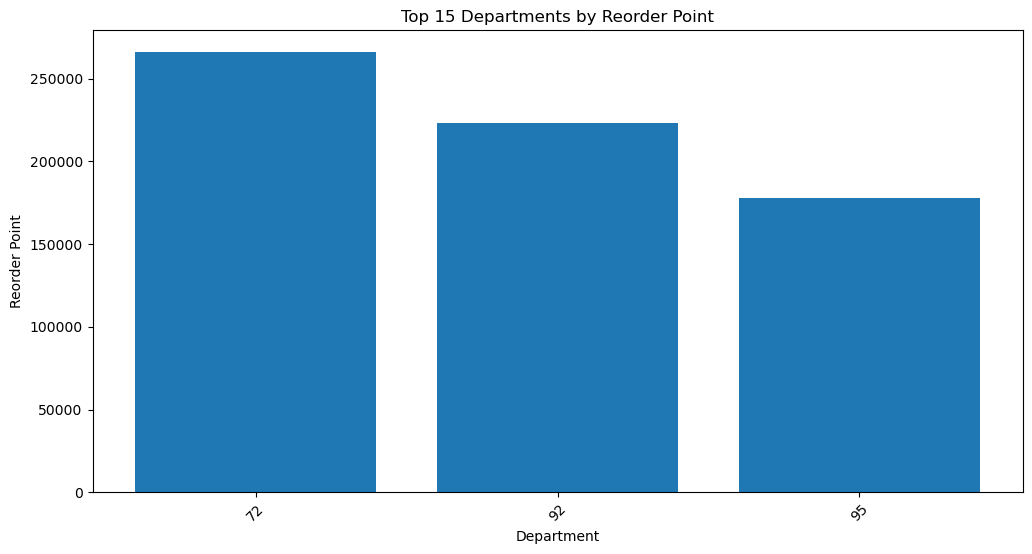

In [11]:
import matplotlib.pyplot as plt

top = inventory.sort_values(
    by="Reorder_Point",
    ascending=False
).head(15)

plt.figure(figsize=(12,6))

plt.bar(top["Dept"].astype(str), top["Reorder_Point"])

plt.title("Top 15 Departments by Reorder Point")

plt.xlabel("Department")

plt.ylabel("Reorder Point")

plt.xticks(rotation=45)

plt.show()

In [15]:
inventory.to_csv(
    "../reports/inventory_recommendations.csv",
    index=False
)